# crosstab-tool — interactive example

This notebook walks through `crosstab-tool` end-to-end against a real, open dataset:
the classic [Titanic passenger manifest](https://github.com/mwaskom/seaborn-data)
(891 rows, bundled locally at `examples/data/titanic.csv` so this notebook runs without
a network connection).

The tool's job is: given a set of **ML model scores**, aggregate them by covariate
features and report descriptive statistics per group ("crosstabs"), optionally
comparing against a baseline. Since the raw Titanic data doesn't come with model
scores, this notebook manufactures a realistic one: it trains a small logistic
regression to predict survival probability, and treats that predicted probability as
the "model score" — a stand-in for e.g. a churn score, a credit score, or a risk score
in a real deployment.

**What this demonstrates** (current milestones — M1 core engine + M2 in-memory adapter):

1. The **file source** path (`CSVSource`) — crosstabbing a column straight from disk,
   no Python-side data prep required.
2. The **in-memory DataFrame source** path (`DataFrameSourceSpec`) — crosstabbing a
   pandas DataFrame produced by an upstream modeling step.
3. The full **v1 stat set** (count/mean/std/min/max/percentile) plus the **non-trivial
   `skew`/`kurtosis`** stats (proving the registry's second, non-expression stat path).
4. **Explicit multi-groupby specs**, including the empty groupset for an overall total.
5. **Filters**, and the **validation guardrails** that catch a bad column name before
   any data is scanned.

Comparison/baseline (M3), cube/auto-groupby (M6), SQL sources (M4), and the CLI (M5)
aren't built yet, so they aren't covered here.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists():
            return path
    raise RuntimeError("Could not locate repo root (no pyproject.toml found above cwd)")


REPO_ROOT = find_repo_root(Path.cwd())
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from crosstab_tool import CrosstabSpec, run_crosstab  # noqa: E402 (needs sys.path set above)

DATA_PATH = REPO_ROOT / "examples" / "data" / "titanic.csv"
assert DATA_PATH.exists(), f"Expected the bundled dataset at {DATA_PATH}"

warnings.filterwarnings("ignore")  # quiet sklearn's convergence chatter for this demo

DATA_PATH

PosixPath('/Users/dsr3/Documents/crosstab-tool/examples/data/titanic.csv')

## 1. Crosstab straight off disk (`CSVSource`)

Before touching any Python data structures, point the tool directly at the raw CSV
and crosstab `fare` by class and sex. This is the file-source path: `pl.scan_csv`
under the hood, so even a 100M+ row file would only ever be lazily scanned, not
eagerly loaded (see `docs/POLARS_SCALE.md`).

In [2]:
fare_spec = CrosstabSpec.model_validate(
    {
        "source": {"type": "csv", "path": str(DATA_PATH)},
        "score_columns": ["fare"],
        "groupby": {
            "type": "explicit",
            "groups": [["sex"], ["pclass"], ["sex", "pclass"]],
        },
        "stats": [
            {"name": "count", "column": "fare"},
            {"name": "mean", "column": "fare"},
            {"name": "percentile", "column": "fare", "params": {"q": 0.5}},
        ],
    }
)

fare_result = run_crosstab(fare_spec)

for key, frame in fare_result.to_pandas().items():
    print(f"\n=== {key} ===")
    display(frame)


=== sex ===


,sex,fare_count,fare_mean,fare_p50
0,male,577,25.523893,10.5
1,female,314,44.479818,23.0



=== pclass ===


,pclass,fare_count,fare_mean,fare_p50
0,3,491,13.675550,8.050
1,1,216,84.154687,61.175
2,2,184,20.662183,14.500



=== sex__pclass ===


,sex,pclass,fare_count,fare_mean,fare_p50
0,male,3,347,12.661633,7.9250
1,female,1,94,106.125798,83.1583
2,female,3,144,16.118810,12.4750
3,male,1,122,67.226127,42.4000
4,female,2,76,21.970121,23.0000
5,male,2,108,19.741782,13.0000


## 2. Train a small model to produce real "scores"

A logistic regression predicting `survived` from `pclass`, `sex`, `age`, `fare`, and
`embarked`. The predicted probability becomes `model_score` — this is the column the
rest of the notebook crosstabs, exactly like a real deployment would crosstab a
churn/credit/risk score. We also bucket `age` into an extra covariate to show a
groupby column that didn't exist in the raw file.

In [3]:
df = pd.read_csv(DATA_PATH)

# Minimal cleaning: fill missing age with the median, drop the couple of rows missing embarked.
df["age"] = df["age"].fillna(df["age"].median())
df = df.dropna(subset=["embarked"]).reset_index(drop=True)

features = ["pclass", "sex", "age", "fare", "embarked"]
categorical = ["pclass", "sex", "embarked"]

preprocess = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), categorical)],
    remainder="passthrough",
)
model = Pipeline([("preprocess", preprocess), ("clf", LogisticRegression(max_iter=1000))])
model.fit(df[features], df["survived"])

df["model_score"] = model.predict_proba(df[features])[:, 1]
df["age_bucket"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["child", "teen", "adult", "middle_age", "senior"],
).astype(str)

df[["survived", "pclass", "sex", "age", "age_bucket", "fare", "embarked", "model_score"]].head()

,survived,pclass,sex,age,age_bucket,fare,embarked,model_score
0,0,3,male,22.0,adult,7.2500,S,0.095402
1,1,1,female,38.0,middle_age,71.2833,C,0.922970
2,1,3,female,26.0,adult,7.9250,S,0.533000
3,1,1,female,35.0,adult,53.1000,S,0.884379
4,0,3,male,35.0,adult,8.0500,S,0.065058


## 3. Crosstab the model score (`DataFrameSourceSpec`)

Now the interesting part: crosstab `model_score` — an in-memory pandas column that
doesn't exist anywhere on disk — across several groupby specs at once, with the full
v1 stat set plus `skew`/`kurtosis`. `DataFrameSourceSpec` is Python-API-only by design
(there's no sensible YAML/JSON form for a live in-memory object — see
`docs/POLARS_SCALE.md`'s note on it), so this is exactly the shape a notebook/pipeline
caller would use.

In [4]:
score_spec = CrosstabSpec.model_validate(
    {
        "source": {"type": "dataframe", "data": df},
        "score_columns": ["model_score"],
        "groupby": {
            "type": "explicit",
            "groups": [
                [],  # "__overall__" -- the whole population, no grouping
                ["sex"],
                ["pclass"],
                ["sex", "pclass"],
                ["age_bucket"],
            ],
        },
        "stats": [
            {"name": "count", "column": "model_score"},
            {"name": "mean", "column": "model_score"},
            {"name": "std", "column": "model_score"},
            {"name": "min", "column": "model_score"},
            {"name": "max", "column": "model_score"},
            {"name": "percentile", "column": "model_score", "params": {"q": 0.5}},
            {"name": "percentile", "column": "model_score", "params": {"q": 0.9}},
            {"name": "skew", "column": "model_score"},
            {"name": "kurtosis", "column": "model_score"},
        ],
        "filters": ["model_score is not null"],
    }
)

score_result = run_crosstab(score_spec)

for key, frame in score_result.to_pandas().items():
    print(f"\n=== {key} ===")
    display(frame)


=== __overall__ ===


,model_score_count,model_score_mean,model_score_std,model_score_min,model_score_max,model_score_p50,model_score_p90,model_score_skew,model_score_kurtosis
0,889,0.382449,0.300303,0.019568,0.961881,0.278187,0.87225,0.535381,-1.178602



=== sex ===


,sex,model_score_count,model_score_mean,model_score_std,model_score_min,model_score_max,model_score_p50,model_score_p90,model_score_skew,model_score_kurtosis
0,male,577,0.191081,0.145228,0.019568,0.661564,0.125832,0.430897,1.307974,0.857299
1,female,312,0.736358,0.157594,0.258918,0.961881,0.750607,0.930435,-0.370497,-0.843162



=== pclass ===


,pclass,model_score_count,model_score_mean,model_score_std,model_score_min,model_score_max,model_score_p50,model_score_p90,model_score_skew,model_score_kurtosis
0,3,491,0.244706,0.236337,0.019568,0.814846,0.112416,0.639874,1.024225,-0.673088
1,1,214,0.621423,0.267011,0.126951,0.961881,0.581587,0.939546,-0.035714,-1.601470
2,2,184,0.472077,0.281600,0.076037,0.937558,0.331972,0.843388,0.280985,-1.644681



=== sex__pclass ===


,sex,pclass,model_score_count,model_score_mean,model_score_std,model_score_min,model_score_max,model_score_p50,model_score_p90,model_score_skew,model_score_kurtosis
0,male,3,347,0.098066,0.035455,0.019568,0.264486,0.090041,0.137219,1.183999,2.845229
1,female,1,92,0.906492,0.042452,0.759807,0.961881,0.919878,0.949700,-1.179442,1.304227
2,female,3,144,0.598070,0.102134,0.258918,0.814846,0.616253,0.722080,-0.325887,0.109262
3,male,1,122,0.406453,0.125560,0.126951,0.661564,0.413851,0.583165,0.144148,-0.730197
4,female,2,76,0.792424,0.074169,0.605417,0.937558,0.796588,0.890969,-0.412173,-0.230988
5,male,2,108,0.246647,0.087077,0.076037,0.564952,0.238960,0.350870,0.690798,0.952890



=== age_bucket ===


,age_bucket,model_score_count,model_score_mean,model_score_std,model_score_min,model_score_max,model_score_p50,model_score_p90,model_score_skew,model_score_kurtosis
0,adult,535,0.356723,0.295222,0.065025,0.958198,0.234213,0.829313,0.661004,-1.008800
1,middle_age,194,0.392148,0.297238,0.031247,0.929733,0.334258,0.873173,0.505101,-1.103159
2,child,69,0.504865,0.282079,0.132904,0.958711,0.581828,0.884693,-0.053953,-1.543009
3,teen,70,0.490210,0.331207,0.107003,0.961881,0.596136,0.933108,0.020092,-1.634969
4,senior,21,0.186851,0.155907,0.019568,0.759807,0.194964,0.258918,2.321148,6.831167


## 4. Validation guardrails

`core/validation.py` checks groupby/stat columns against the source's schema (and
numeric-dtype requirements for stats like `mean`) before any data is scanned or
collected — so a typo fails fast with a clear message instead of a confusing Polars
error deep in the execution engine.

In [5]:
bad_spec = CrosstabSpec.model_validate(
    {
        "source": {"type": "dataframe", "data": df},
        "score_columns": ["model_score"],
        "groupby": {"type": "explicit", "groups": [["not_a_real_column"]]},
        "stats": [{"name": "mean", "column": "model_score"}],
    }
)

try:
    run_crosstab(bad_spec)
except ValueError as exc:
    print(f"Caught expected validation error:\n  {exc}")

Caught expected validation error:
  groupby column 'not_a_real_column' not found in source schema


## 5. A quick look: mean score by passenger class

First class passengers should show a noticeably higher mean predicted survival score
than third class -- a sanity check that the crosstab lines up with what we already
know about the Titanic.

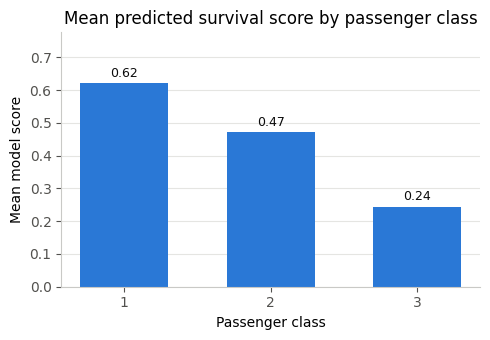

In [6]:
pclass_df = score_result.frames["pclass"].to_pandas().sort_values("pclass")

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(
    pclass_df["pclass"].astype(str),
    pclass_df["model_score_mean"],
    color="#2a78d6",
    width=0.6,
)

ax.set_title("Mean predicted survival score by passenger class")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Mean model score")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c9c9c6")
ax.tick_params(colors="#52514e")
ax.yaxis.grid(True, color="#e5e5e2", linewidth=0.8)
ax.set_axisbelow(True)
ax.set_ylim(0, pclass_df["model_score_mean"].max() * 1.25)

for bar, value in zip(bars, pclass_df["model_score_mean"]):  # noqa: B905 (same length by construction)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        color="#0b0b0b",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

## Where to go from here

- `examples/configs/*.yaml` show the same specs as declarative config (once
  `spec/serde.py` lands in M5, `xtab run --config explicit_groupbys.yaml` will run this
  same kind of spec from the CLI instead of Python).
- `docs/POLARS_SCALE.md` explains how this scales to 100M+ rows and many groupbys.
- `docs/implementation-plan.md` has the full milestone roadmap — M3 (counterfactual
  comparison against a baseline score), M4 (SQL sources), M6 (cube/auto-groupby), and
  M7 (exporters + extensibility polish) are next.